# Advanced AI Medical Intelligence Platform

### Phase 1: Dataset Exploration & EDA

In [1]:
# import libraries
import os
import cv2
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image

In [2]:
# accessing dataset from kaggle
!pip install kaggle -q

!kaggle datasets download sivanarayanamuppidi/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/sivanarayanamuppidi/chest-xray-pneumonia
License(s): apache-2.0
100% 1.14G/1.14G [00:10<00:00, 121MB/s]



In [3]:
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
# define dataset path
DATASET_PATH = "/content/chest_xray"

train_path = os.path.join(DATASET_PATH, "train")
val_path = os.path.join(DATASET_PATH, "val")
test_path = os.path.join(DATASET_PATH, "test")

In [5]:
# verify folder structure
print("Train folders:", os.listdir(train_path))
print("Validation folders:", os.listdir(val_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['NORMAL', 'PNEUMONIA']
Validation folders: ['NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', 'PNEUMONIA']


In [6]:
# Count Images in each folder
def count_images(folder):
    counts = {}

    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)

        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))

    return counts

In [7]:
train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

print("Training Set")
print(train_counts)

print("\nValidation Set")
print(val_counts)

print("\nTest Set")
print(test_counts)

Training Set
{'NORMAL': 1341, 'PNEUMONIA': 3875}

Validation Set
{'NORMAL': 8, 'PNEUMONIA': 8}

Test Set
{'NORMAL': 234, 'PNEUMONIA': 390}


In [8]:
# Create a summary table
summary = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})

summary

,Train,Validation,Test
NORMAL,1341,8,234
PNEUMONIA,3875,8,390


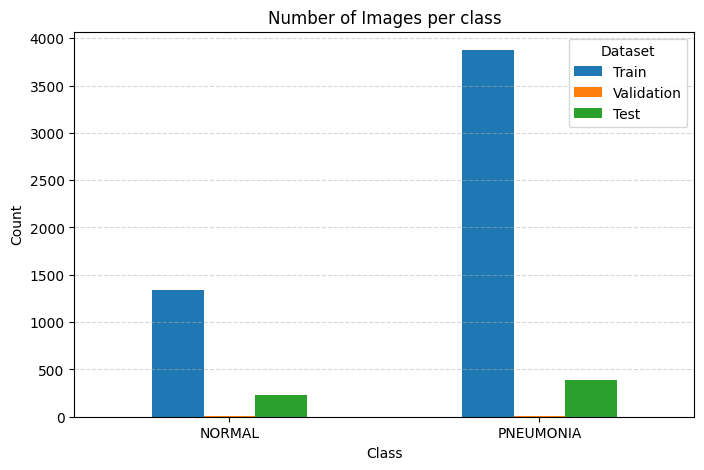

In [9]:
# Visualize class distribution
summary.plot(kind='bar', figsize=(8, 5))
plt.title('Number of Images per class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Dataset')
plt.show()

In [10]:
# Display Sample Images
def show_samples(folder, class_name, n=5):

    class_path = os.path.join(folder, class_name)

    images = random.sample(os.listdir(class_path), n)

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(images):

        img = Image.open(os.path.join(class_path, img_name))

        plt.subplot(1,n,i+1)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

    plt.show()

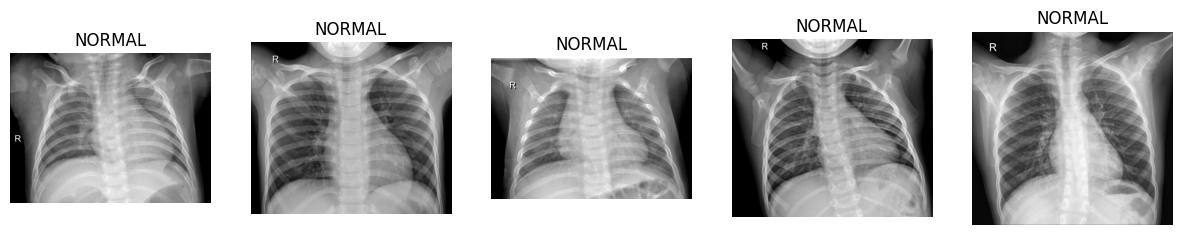

In [11]:
# Normal samples
show_samples(train_path, "NORMAL")

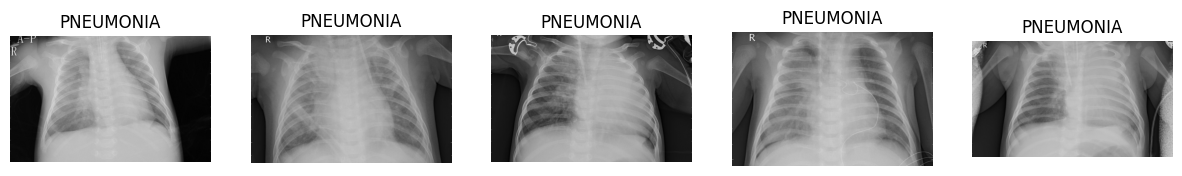

In [12]:
# Pneumonia samples
show_samples(train_path, "PNEUMONIA")

In [13]:
# Check img dimensions
sizes = []

for cls in ["NORMAL", "PNEUMONIA"]:

    cls_path = os.path.join(train_path, cls)

    for img_name in os.listdir(cls_path)[:100]:

        img = Image.open(os.path.join(cls_path, img_name))

        sizes.append(img.size)

In [14]:
# Display few sizes
sizes[:10]

[(1600, 1229),
 (2890, 2534),
 (1832, 1472),
 (1460, 1279),
 (1546, 1425),
 (1500, 1194),
 (1688, 1469),
 (1542, 1032),
 (1682, 1418),
 (1310, 951)]

In [15]:
# Find unique img sizes
unique_sizes = set(sizes)
list(unique_sizes)[:10]

[(1488, 1094),
 (1056, 552),
 (1700, 1368),
 (1522, 1407),
 (1056, 680),
 (1460, 1279),
 (1968, 1484),
 (1056, 808),
 (1654, 1364),
 (1088, 696)]

### Phase 2: Data Preprocessing

In [16]:
# Import required libraries
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

In [17]:
# Set img parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32

In [18]:
# Create ImageDataGenerator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [19]:
# Create Test Generator
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [20]:
# Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 4173 images belonging to 2 classes.


In [21]:
# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1043 images belonging to 2 classes.


In [22]:
# Load test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [23]:
# Check class labels
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [24]:
# Check dataset shapes
print("Training Batches :", len(train_generator))
print("Validation Batches :", len(validation_generator))
print("Testing Batches :", len(test_generator))

Training Batches : 131
Validation Batches : 33
Testing Batches : 20


In [25]:
# Display one batch
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


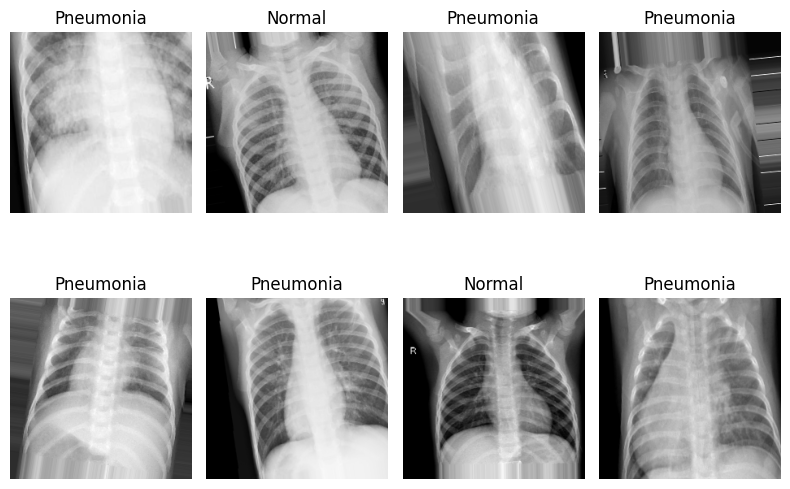

In [28]:
# Visualize augmented images
plt.figure(figsize=(8,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)

    plt.title("Pneumonia" if labels[i] == 1 else "Normal")

    plt.axis("off")

plt.tight_layout()
plt.show()

### Phase 3: Build the Deep Learning Model

In [29]:
# Import required libraries
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

In [30]:
# Load Pre-trained EfficientNet80
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
# Freeze the base model
base_model.trainable = False

In [32]:
# Verify freeze
print("Base Model Trainable:", base_model.trainable)

Base Model Trainable: False


In [33]:
# Build Classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [34]:
# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Compile the model
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=1e-4
)
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [36]:
# Create callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [37]:
# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [38]:
# Save the best model
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [39]:
# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

In [40]:
# Class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [41]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.7960 - loss: 0.4433
Epoch 1: val_accuracy improved from None to 0.89933, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8327 - loss: 0.3636 - val_accuracy: 0.8993 - val_loss: 0.2594 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.8937 - loss: 0.2519
Epoch 2: val_accuracy improved from 0.89933 to 0.91275, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 821ms/step - accuracy: 0.8948 - loss: 0.2445 - val_accuracy: 0.9128 - val_loss: 0.2055 - learning_rate: 1.0000e-04
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9107 - loss: 0.2107
Epoch 3: val_accuracy improved from 0.91275 to 0.92522, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━

In [98]:
# Save the final model
model.save("medical_model.keras")

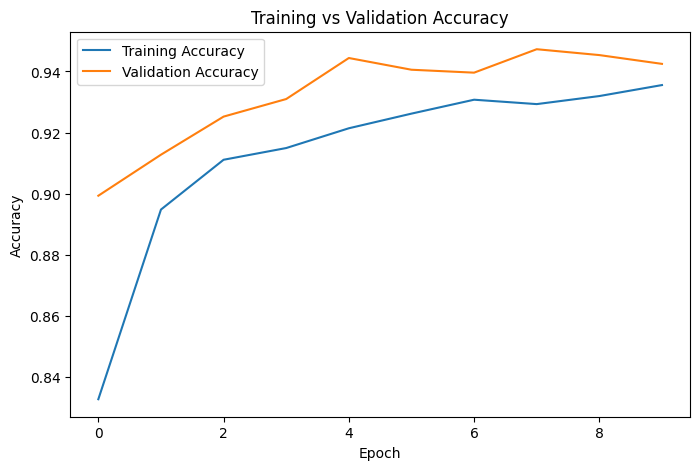

In [99]:
# Plot training curves (Accurary)
plt.figure(figsize=(8,5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

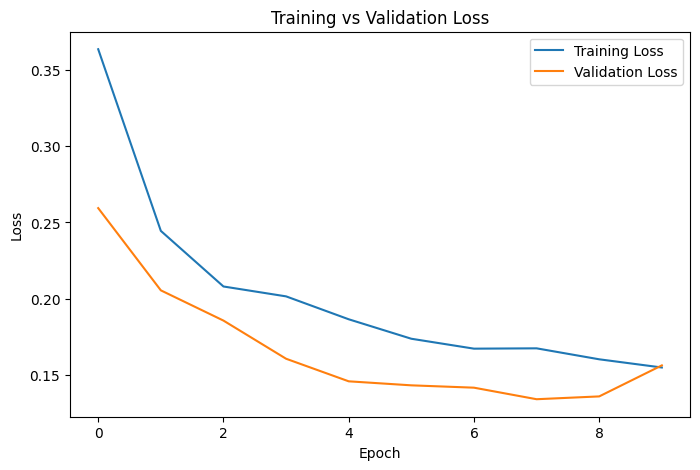

In [100]:
# Plot training curves (Loss)
plt.figure(figsize=(8,5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Phase 4: Model Evaluation

In [101]:
# Load the best model
from tensorflow.keras.models import load_model
best_model = load_model("best_model.keras")

In [102]:
# Evaluate on test dataset
test_loss, test_accuracy = best_model.evaluate(test_generator)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 467ms/step - accuracy: 0.8702 - loss: 0.2828
Test Loss : 0.2828
Test Accuracy : 0.8702


In [103]:
# Predict on test images
predictions = best_model.predict(test_generator)
predictions = (predictions > 0.5).astype(int)
predictions = predictions.flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 655ms/step


In [104]:
# Get true labels
true_labels = test_generator.classes

In [105]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(
    true_labels,
    predictions,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.89      0.74      0.81       234
   PNEUMONIA       0.86      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.86       624
weighted avg       0.87      0.87      0.87       624



In [106]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predictions)
print(cm)

[[174  60]
 [ 21 369]]


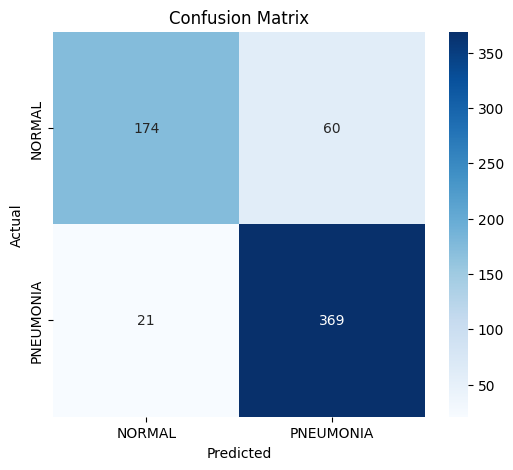

In [107]:
# Visalize the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [108]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

probabilities = best_model.predict(test_generator).ravel()
fpr, tpr, _ = roc_curve(true_labels, probabilities)
roc_auc = auc(fpr, tpr)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step


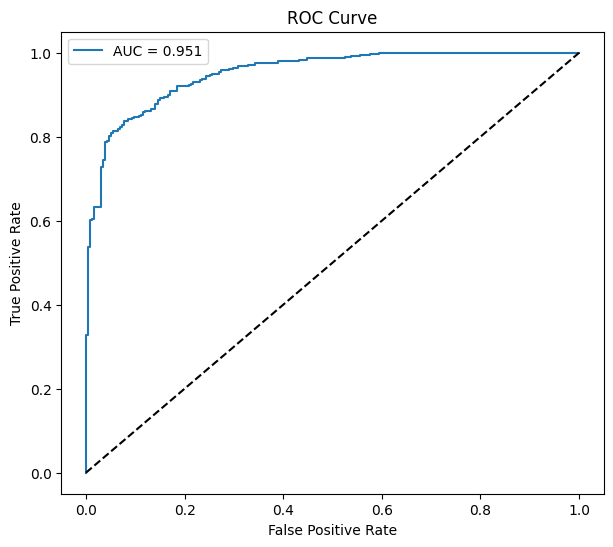

In [109]:
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


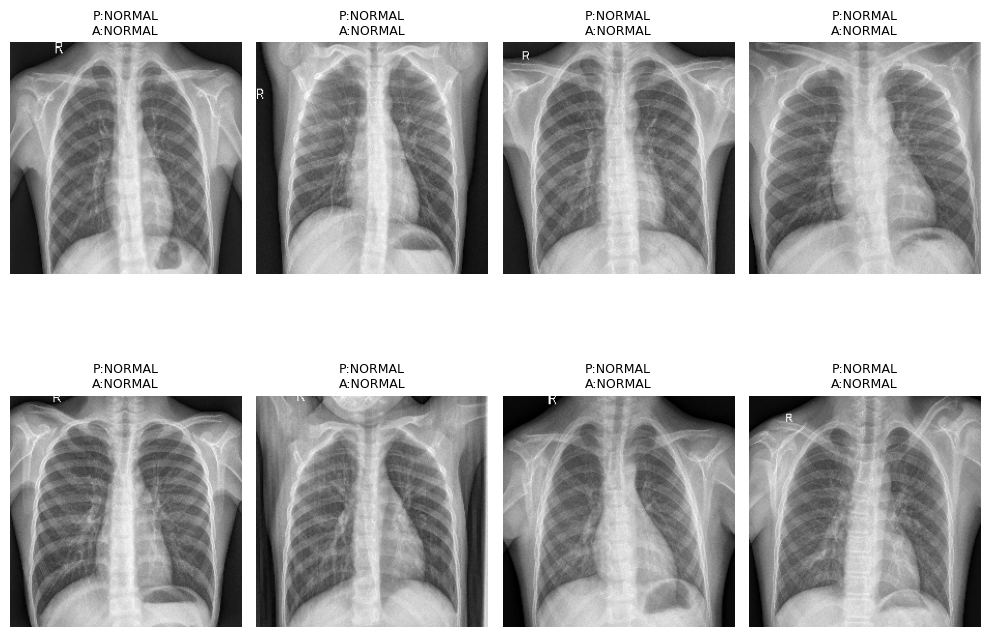

In [110]:
# Display Sample Predictions
import random

test_generator.reset()
images, labels = next(test_generator)
pred = best_model.predict(images)
plt.figure(figsize=(10,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i]
    img = (img - img.min())/(img.max()-img.min())
    plt.imshow(img)

    predicted = "PNEUMONIA" if pred[i] > 0.5 else "NORMAL"
    actual = "PNEUMONIA" if labels[i] else "NORMAL"
    plt.title(f"P:{predicted}\nA:{actual}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Phase 5 – Explainable AI (Grad-CAM)

In [111]:
# Find the convolutional layer
for layer in model.layers:
    print(layer.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [112]:
for layer in base_model.layers[-20:]:
    print(layer.name)

block6d_project_conv
block6d_project_bn
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [160]:
# Load one test image
normal_path = os.path.join(test_path, "NORMAL")
pneumonia_path = os.path.join(test_path, "PNEUMONIA")

image_path = os.path.join(
    pneumonia_path,
    random.choice(os.listdir(pneumonia_path))
)

print(image_path)

/content/chest_xray/test/PNEUMONIA/person124_bacteria_590.jpeg


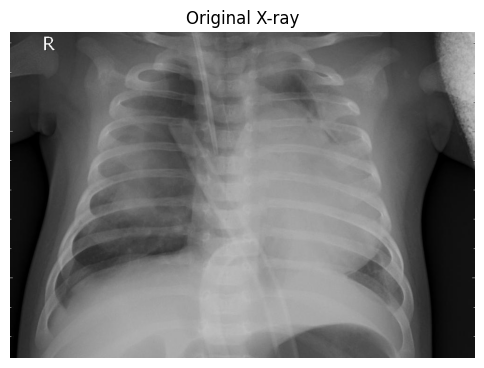

In [161]:
# Display original image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original X-ray")
plt.axis("off")
plt.show()

In [162]:
# Preprocess image
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img, axis=0)
img_array = preprocess_input(img_array)

In [163]:
# Predict
prediction = model.predict(img_array)[0][0]
if prediction > 0.5:
    print("Prediction : PNEUMONIA")
    print("Confidence :", prediction)
else:
    print("Prediction : NORMAL")
    print("Confidence :", 1-prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction : PNEUMONIA
Confidence : 0.9920631


In [164]:
# Build the Grad-CAM Model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("top_conv").output,
        model.output
    ]
)

In [165]:
# Verify
print(grad_model.output)

[<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_235>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_242>]


In [166]:
# Compute gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]
grads = tape.gradient(loss, conv_outputs)

In [167]:
print(conv_outputs.shape)
print(grads.shape)

(1, 7, 7, 1280)
(1, 7, 7, 1280)


In [168]:
# Remove batch dimension
conv_outputs = conv_outputs[0]      # (7, 7, 1280)
grads = grads[0]                    # (7, 7, 1280)

# Compute importance of each channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

# Weight each feature map
conv_outputs = conv_outputs * pooled_grads

# Sum over channels -> single heatmap
heatmap = tf.reduce_sum(conv_outputs, axis=-1)

# Convert to NumPy
heatmap = heatmap.numpy()

print("Heatmap shape:", heatmap.shape)

Heatmap shape: (7, 7)


In [169]:
print("Min:", heatmap.min())
print("Max:", heatmap.max())
print("Mean:", heatmap.mean())

Min: 0.0007555299
Max: 0.0022929676
Mean: 0.0016460952


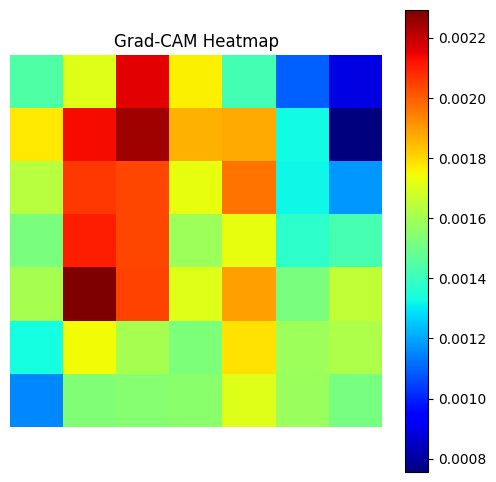

In [170]:
# Display heatmap
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

In [172]:
# Normalization
heatmap = np.maximum(heatmap, 0)

if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

print("After normalization")
print("Min:", heatmap.min())
print("Max:", heatmap.max())

After normalization
Min: 0.32949874
Max: 1.0


In [173]:
# Heatmap resize
heatmap = cv2.resize(
    heatmap,
    (224, 224)
)

print("After resize:", heatmap.shape)

After resize: (224, 224)


In [174]:
# Convert to colored heatmap
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

print(heatmap.min(), heatmap.max(), heatmap.dtype)

0 255 uint8


In [175]:
print(heatmap.shape)

(224, 224, 3)


In [176]:
# Save the heatmap before overlay
cv2.imwrite(
    "heatmap_only.png",
    heatmap
)

True

In [178]:
# Overlay on original img
overlay = cv2.addWeighted(
    img,
    0.6,
    heatmap,
    0.4,
    0
)

In [179]:
print("Original Image:", img.shape, img.dtype)
print("Heatmap:", heatmap.shape, heatmap.dtype)

Original Image: (224, 224, 3) uint8
Heatmap: (224, 224, 3) uint8


In [180]:
# Save the original image separately
cv2.imwrite("original_debug.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

True

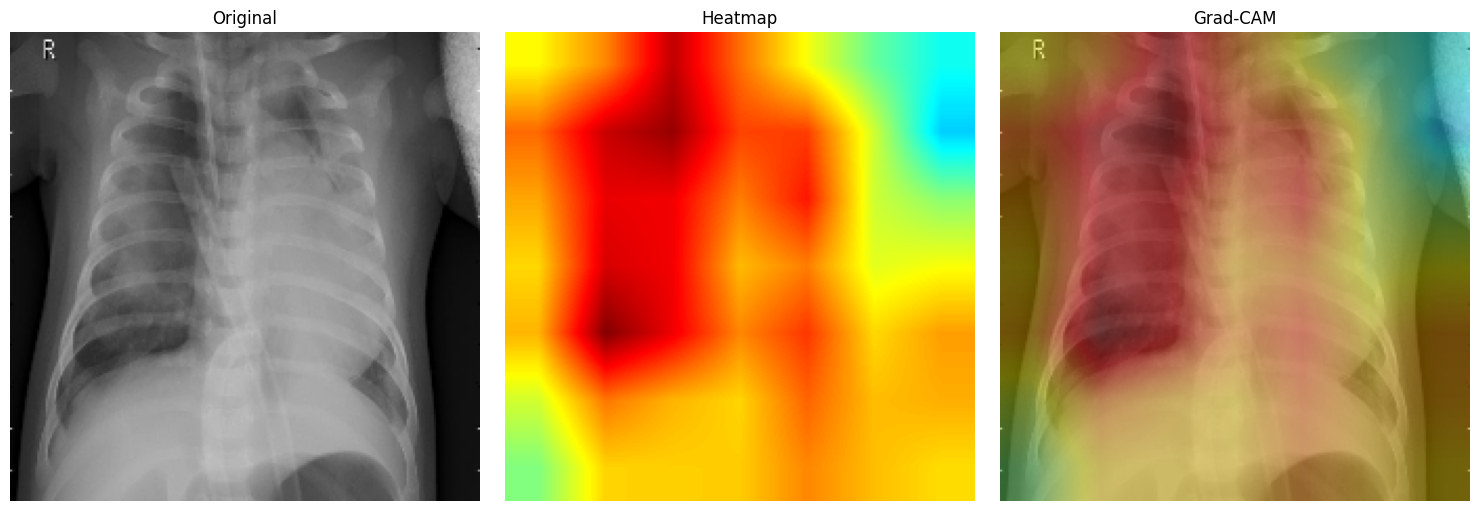

In [181]:
# Final result
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [182]:
# Save result
cv2.imwrite(
    "gradcam_result.png",
    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
)

True

### Phase 6 – AI Medical Report Generation

In [184]:
# Configure API & Import required libraries
!pip install -q groq
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

In [185]:
# Create the client
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

In [186]:
# Test the connection
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "user",
            "content": "Say hello in one sentence."
        }
    ]
)

print(response.choices[0].message.content)

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [187]:
# Build reusable report function
def generate_medical_report(prediction, confidence):
    prompt = f"""
You are an experienced radiologist.

An AI model analyzed a chest X-ray.

Prediction:
{prediction}

Confidence:
{confidence:.2f}%

Generate a structured report with the following sections:

1. Prediction Summary
2. Possible Findings
3. Clinical Interpretation
4. Possible Symptoms
5. Recommended Next Steps
6. Precautions
7. Disclaimer

Keep the report professional and concise.
Mention that this report is AI-assisted and should not replace professional medical advice.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.3,
        max_tokens=700
    )

    return response.choices[0].message.content

In [188]:
# Testing function
report = generate_medical_report(
    prediction="PNEUMONIA",
    confidence=95.49
)

print(report)

**AI-Assisted Radiology Report**

**1. Prediction Summary**
The AI model has analyzed the chest X-ray and predicts the presence of PNEUMONIA with a confidence level of 95.49%.

**2. Possible Findings**
The X-ray may show signs of lung consolidation, infiltrates, or opacities, which are consistent with pneumonia. However, the AI model's prediction is based on patterns and algorithms, and a thorough review by a qualified radiologist is necessary to confirm these findings.

**3. Clinical Interpretation**
Pneumonia is an infection that inflames the air sacs in the lungs, which can be caused by bacteria, viruses, or fungi. The high confidence level of the AI model's prediction suggests a strong likelihood of pneumonia, but clinical correlation and further evaluation are necessary to determine the severity and type of infection.

**4. Possible Symptoms**
The patient may be experiencing symptoms such as cough, fever, chest pain, shortness of breath, or fatigue, which are commonly associated w